In [2]:
# Cell 1
%load_ext autoreload
%autoreload 2

import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"


In [3]:
# Cell 2
from src.utils_RCNN import *

train_dataset = WildlifeYOLODataset(
    images_dir="data/format_rgb/images/train",
    labels_dir="data/format_rgb/labels/train",
    transforms=get_transform(train=True),
)

val_dataset = WildlifeYOLODataset(
    images_dir="data/format_rgb/images/val",
    labels_dir="data/format_rgb/labels/val",
    transforms=get_transform(train=False),
)

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset,
    batch_size=2,      
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn,
)


/Users/florenciazoffi/miniconda3/envs/dronergbt/lib/python3.11/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/Users/florenciazoffi/miniconda3/envs/dronergbt/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <EB3FF92A-5EB1-3EE8-AF8B-5923C1265422> /Users/florenciazoffi/miniconda3/envs/dronergbt/lib/python3.11/site-packages/torchvision/image.so
  Reason: tried: '/Users/florenciazoffi/miniconda3/envs/dronergbt/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/florenciazoffi/miniconda3/envs/dronergbt/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/florenciazoffi/miniconda3/envs/dronergbt/lib/python3.11/lib-dynload/../../libjpeg.9.dylib' (no such file), '/Users/florenciazoffi/miniconda3/envs/dronergbt/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functio

In [4]:
# Cell 5
from pathlib import Path
import yaml
import csv
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# =========================
# 1) Carpeta de experimento
# =========================
RUNS_DIR = Path("runs/fasterrcnn")   # similar a runs/detect de YOLO
RUNS_DIR.mkdir(parents=True, exist_ok=True)

# nombre tipo wildlife_t_from_rgb_v8n_cpu
exp_name = "wildlife_t_from_rgb_frcnn_cpu"
EXP_DIR = RUNS_DIR / exp_name
WEIGHTS_DIR = EXP_DIR / "weights"
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

results_file = EXP_DIR / "results.csv"
args_file = EXP_DIR / "args.yaml"


In [5]:
# Cell 6
# =========================
# 2) Guardar args.yaml
# =========================
args = {
    "model": "fasterrcnn_resnet50_fpn",
    "num_classes": 3 + 1,
    "epochs": 10,
    "batch_size": 2,
    "lr": 0.005,
    "momentum": 0.9,
    "weight_decay": 0.0005,
    "train_images": str(train_dataset.images_dir),
    "val_images": str(val_dataset.images_dir),
    "train_labels": str(train_dataset.labels_dir),
    "val_labels": str(val_dataset.labels_dir),
    "device": "cpu",
}
with open(args_file, "w") as f:
    yaml.safe_dump(args, f)


In [6]:
# Cell 7
# =========================
# 3) Modelo y optimizador
# =========================
device = torch.device("cpu")
print("Entrenando en", device)

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

num_classes = 3 + 1  # Cow, Deer, Horse + background
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params,
    lr=args["lr"],
    momentum=args["momentum"],
    weight_decay=args["weight_decay"],
)

num_epochs = args["epochs"]

# preparar CSV con header
with open(results_file, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["epoch", "train_loss", "val_loss", "lr"])

best_val_loss = float("inf")


Entrenando en cpu


In [7]:
# Cell 8
# =========================
# 4) Loop de entrenamiento con log + checkpoints
# =========================
for epoch in range(num_epochs):
    # --------- entrenamiento ----------
    model.train()
    train_loss = 0.0

    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)         # devuelve dict de pérdidas
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        train_loss += losses.item()

    train_loss /= len(train_loader)

    # --------- validación (misma loss de detección) ----------
    # OJO: tiene que estar en train() para devolver loss_dict,
    # pero con no_grad() para no calcular gradientes
    val_loss = 0.0
    model.train()
    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)     # otra vez dict de pérdidas
            losses = sum(loss for loss in loss_dict.values())
            val_loss += losses.item()

    val_loss /= len(val_loader)

    # learning rate actual (por si después usás scheduler)
    current_lr = optimizer.param_groups[0]["lr"]

    # log a CSV
    with open(results_file, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([epoch + 1, train_loss, val_loss, current_lr])

    # guardar last.pt siempre
    torch.save(model.state_dict(), WEIGHTS_DIR / "last.pt")

    # actualizar best.pt si mejora val_loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), WEIGHTS_DIR / "best.pt")

    print(
        f"Epoch {epoch+1}/{num_epochs} - "
        f"train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f}"
    )

print("Entrenamiento terminado. Pesos en:", WEIGHTS_DIR)
print("Resultados en:", results_file)
print("Args en:", args_file)


Epoch 1/10 - train_loss: 0.5849 - val_loss: 0.4775
Epoch 2/10 - train_loss: 0.3851 - val_loss: 0.3810
Epoch 3/10 - train_loss: 0.3112 - val_loss: 0.3560
Epoch 4/10 - train_loss: 0.2764 - val_loss: 0.3721
Epoch 5/10 - train_loss: 0.2416 - val_loss: 0.3605
Epoch 6/10 - train_loss: 0.2307 - val_loss: 0.3731
Epoch 7/10 - train_loss: 0.2070 - val_loss: 0.3788
Epoch 8/10 - train_loss: 0.2056 - val_loss: 0.3546
Epoch 9/10 - train_loss: 0.1789 - val_loss: 0.4164
Epoch 10/10 - train_loss: 0.1708 - val_loss: 0.3793
Entrenamiento terminado. Pesos en: runs/fasterrcnn/wildlife_t_from_rgb_frcnn_cpu/weights
Resultados en: runs/fasterrcnn/wildlife_t_from_rgb_frcnn_cpu/results.csv
Args en: runs/fasterrcnn/wildlife_t_from_rgb_frcnn_cpu/args.yaml


In [8]:
# Cell X - Evaluación en el conjunto de validación (mAP + métricas de clasificación)

import numpy as np

# Asumimos ids de clase 1,2,3 (Cow, Deer, Horse) y 0 = background
CLASS_NAMES = {
    1: "Cow",
    2: "Deer",
    3: "Horse",
}

IOU_THRESHOLDS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

def box_iou(box1, box2):
    """
    box1: [4]  (x1, y1, x2, y2)
    box2: [4]
    """
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0.0, x2 - x1)
    inter_h = max(0.0, y2 - y1)
    inter = inter_w * inter_h

    area1 = max(0.0, (box1[2] - box1[0])) * max(0.0, (box1[3] - box1[1]))
    area2 = max(0.0, (box2[2] - box2[0])) * max(0.0, (box2[3] - box2[1]))

    union = area1 + area2 - inter
    if union <= 0:
        return 0.0
    return inter / union


def compute_ap(precision, recall):
    """
    AP como área bajo la curva P-R (regla del trapecio).
    precision, recall: arrays ordenados por recall creciente.
    """
    # aseguramos orden por recall
    idx = np.argsort(recall)
    recall = recall[idx]
    precision = precision[idx]

    # integración numérica simple
    ap = 0.0
    for i in range(1, len(recall)):
        ap += (recall[i] - recall[i - 1]) * (precision[i] + precision[i - 1]) / 2.0
    return ap


def evaluate_fasterrcnn(model, data_loader, device, iou_thresholds=IOU_THRESHOLDS, num_classes=3):
    model.eval()
    all_metrics = {}

    # Para métricas de clasificación globales (usamos IoU=0.5)
    global_tp = 0
    global_fp = 0
    global_fn = 0

    # Para contabilizar AP por clase e IoU
    # Por cada clase y umbral guardamos (scores, tp_flags, num_gt)
    per_class_data = {
        thr: {
            cls_id: {
                "scores": [],
                "tp_flags": [],
                "num_gt": 0,
            }
            for cls_id in range(1, num_classes + 1)
        }
        for thr in iou_thresholds
    }

    with torch.no_grad():
        for images, targets in data_loader:
            images = [img.to(device) for img in images]
            # targets en CPU para facilidad
            targets = [{k: v.to("cpu") for k, v in t.items()} for t in targets]

            outputs = model(images)

            for out, tgt in zip(outputs, targets):
                gt_boxes = tgt["boxes"].cpu().numpy()
                gt_labels = tgt["labels"].cpu().numpy()

                pred_boxes = out["boxes"].cpu().numpy()
                pred_scores = out["scores"].cpu().numpy()
                pred_labels = out["labels"].cpu().numpy()

                # Ordenar predicciones por score descendente
                order = np.argsort(-pred_scores)
                pred_boxes = pred_boxes[order]
                pred_scores = pred_scores[order]
                pred_labels = pred_labels[order]

                # Para cada IoU threshold, hacemos matching independiente
                for thr in iou_thresholds:
                    # Para no mezclar matches entre thresholds
                    gt_matched = np.zeros(len(gt_boxes), dtype=bool)

                    for pb, ps, pl in zip(pred_boxes, pred_scores, pred_labels):
                        if pl == 0:  # ignoramos background
                            continue

                        best_iou = 0.0
                        best_gt_idx = -1
                        for j, (gb, gl) in enumerate(zip(gt_boxes, gt_labels)):
                            if gl != pl:
                                continue
                            iou = box_iou(pb, gb)
                            if iou > best_iou:
                                best_iou = iou
                                best_gt_idx = j

                        is_tp = False
                        if best_iou >= thr and best_gt_idx >= 0 and not gt_matched[best_gt_idx]:
                            is_tp = True
                            gt_matched[best_gt_idx] = True

                        pc = per_class_data[thr][int(pl)]
                        pc["scores"].append(ps)
                        pc["tp_flags"].append(1 if is_tp else 0)

                    # total de GT por clase (para este thr) aumenta
                    # (igual para todos los thr, pero lo repetimos para simplicidad)
                    for gl in gt_labels:
                        if gl == 0:
                            continue
                        per_class_data[thr][int(gl)]["num_gt"] += 1

                # Para métricas de clasificación global (IoU=0.5)
                thr = 0.5
                gt_matched_global = np.zeros(len(gt_boxes), dtype=bool)

                for pb, ps, pl in zip(pred_boxes, pred_scores, pred_labels):
                    if pl == 0:
                        continue
                    best_iou = 0.0
                    best_gt_idx = -1
                    for j, (gb, gl) in enumerate(zip(gt_boxes, gt_labels)):
                        if gl != pl:
                            continue
                        iou = box_iou(pb, gb)
                        if iou > best_iou:
                            best_iou = iou
                            best_gt_idx = j
                    if best_iou >= thr and best_gt_idx >= 0 and not gt_matched_global[best_gt_idx]:
                        global_tp += 1
                        gt_matched_global[best_gt_idx] = True
                    else:
                        global_fp += 1

                # cualquier gt no matcheado es FN
                global_fn += int((~gt_matched_global).sum())

    # ---- Calcular AP por clase para cada IoU y mAP ----
    mAP_50 = 0.0
    mAP_50_90 = 0.0
    valid_classes_50 = 0
    valid_classes_5090 = 0

    ap_per_class_iou = {thr: {} for thr in iou_thresholds}

    for thr in iou_thresholds:
        for cls_id in range(1, num_classes + 1):
            data = per_class_data[thr][cls_id]
            scores = np.array(data["scores"])
            tp_flags = np.array(data["tp_flags"])
            num_gt = data["num_gt"]

            if num_gt == 0:
                ap = np.nan
            else:
                # ordenar por score
                order = np.argsort(-scores)
                scores = scores[order]
                tp_flags = tp_flags[order]

                fp_flags = 1 - tp_flags

                cum_tp = np.cumsum(tp_flags)
                cum_fp = np.cumsum(fp_flags)

                precision = cum_tp / np.maximum(cum_tp + cum_fp, 1e-8)
                recall = cum_tp / max(num_gt, 1)

                ap = compute_ap(precision, recall)

            ap_per_class_iou[thr][CLASS_NAMES[cls_id]] = ap

        # mAP para este thr
        valid_aps = [v for v in ap_per_class_iou[thr].values() if not np.isnan(v)]
        mAP_thr = float(np.mean(valid_aps)) if len(valid_aps) > 0 else float("nan")

        if abs(thr - 0.5) < 1e-6:
            mAP_50 = mAP_thr
            valid_classes_50 = len(valid_aps)

        # para mAP@0.5:0.9 acumulamos luego
        if len(valid_aps) > 0:
            mAP_50_90 += mAP_thr
            valid_classes_5090 += 1

    mAP_50_90 = mAP_50_90 / max(len(iou_thresholds), 1)

    # ---- Métricas de clasificación globales ----
    precision_global = global_tp / max(global_tp + global_fp, 1)
    recall_global = global_tp / max(global_tp + global_fn, 1)
    f1_global = 0.0
    if precision_global + recall_global > 0:
        f1_global = 2 * precision_global * recall_global / (precision_global + recall_global)

    accuracy_global = global_tp / max(global_tp + global_fp + global_fn, 1)

    metrics = {
        "mAP@0.5": mAP_50,
        "mAP@0.5:0.9": mAP_50_90,
        "AP_per_class": ap_per_class_iou,   # dict[IoU][class_name] = AP
        "precision": precision_global,
        "recall": recall_global,
        "f1": f1_global,
        "accuracy": accuracy_global,
    }
    return metrics


# ---------------------------
# Ejecutar evaluación y print
# ---------------------------

# opcional: si querés asegurarte de usar los mejores pesos guardados
# model.load_state_dict(torch.load(WEIGHTS_DIR / "best.pt", map_location=device))

metrics = evaluate_fasterrcnn(model, val_loader, device)

print("\n===== Métricas Faster R-CNN (val) =====")
print(f"mAP@0.5      : {metrics['mAP@0.5']:.4f}")
print(f"mAP@0.5:0.9  : {metrics['mAP@0.5:0.9']:.4f}")
print(f"Accuracy     : {metrics['accuracy']:.4f}")
print(f"Precision    : {metrics['precision']:.4f}")
print(f"Recall       : {metrics['recall']:.4f}")
print(f"F1           : {metrics['f1']:.4f}")

print("\nAP por clase y IoU:")
for thr in IOU_THRESHOLDS:
    print(f"\n  IoU = {thr}")
    for cls_name, ap in metrics["AP_per_class"][thr].items():
        if np.isnan(ap):
            print(f"    {cls_name}: AP = N/A (sin GT)")
        else:
            print(f"    {cls_name}: AP = {ap:.4f}")



===== Métricas Faster R-CNN (val) =====
mAP@0.5      : 0.8136
mAP@0.5:0.9  : 0.6291
Accuracy     : 0.5133
Precision    : 0.5580
Recall       : 0.8652
F1           : 0.6784

AP por clase y IoU:

  IoU = 0.1
    Cow: AP = 0.8479
    Deer: AP = 0.7233
    Horse: AP = 0.9562

  IoU = 0.2
    Cow: AP = 0.8479
    Deer: AP = 0.7233
    Horse: AP = 0.9562

  IoU = 0.3
    Cow: AP = 0.8104
    Deer: AP = 0.7233
    Horse: AP = 0.9562

  IoU = 0.4
    Cow: AP = 0.7884
    Deer: AP = 0.7233
    Horse: AP = 0.9562

  IoU = 0.5
    Cow: AP = 0.7615
    Deer: AP = 0.7233
    Horse: AP = 0.9562

  IoU = 0.6
    Cow: AP = 0.6453
    Deer: AP = 0.5869
    Horse: AP = 0.9562

  IoU = 0.7
    Cow: AP = 0.1908
    Deer: AP = 0.2016
    Horse: AP = 0.9172

  IoU = 0.8
    Cow: AP = 0.0570
    Deer: AP = 0.0213
    Horse: AP = 0.8774

  IoU = 0.9
    Cow: AP = 0.0002
    Deer: AP = 0.0000
    Horse: AP = 0.0778


In [9]:
# ================================
#  Métricas en TEST (mAP, AP, etc.)
# ================================

# Crear dataset y dataloader de test (usando misma estructura que train/val)
test_dataset = WildlifeYOLODataset(
    images_dir="data/format_rgb/images/test",
    labels_dir="data/format_rgb/labels/test",
    transforms=get_transform(train=False),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn,
)

# Evaluar usando la misma función que en validation
metrics_test = evaluate_fasterrcnn(model, test_loader, device)

print("\n===== Métricas Faster R-CNN (TEST) =====")
print(f"mAP@0.5      : {metrics_test['mAP@0.5']:.4f}")
print(f"mAP@0.5:0.9  : {metrics_test['mAP@0.5:0.9']:.4f}")
print(f"Accuracy     : {metrics_test['accuracy']:.4f}")
print(f"Precision    : {metrics_test['precision']:.4f}")
print(f"Recall       : {metrics_test['recall']:.4f}")
print(f"F1           : {metrics_test['f1']:.4f}")

print("\nAP por clase y IoU:")
for thr in IOU_THRESHOLDS:
    print(f"\n  IoU = {thr}")
    for cls_name, ap in metrics_test["AP_per_class"][thr].items():
        if np.isnan(ap):
            print(f"    {cls_name}: AP = N/A")
        else:
            print(f"    {cls_name}: AP = {ap:.4f}")



===== Métricas Faster R-CNN (TEST) =====
mAP@0.5      : 0.8500
mAP@0.5:0.9  : 0.6443
Accuracy     : 0.5146
Precision    : 0.5248
Recall       : 0.9636
F1           : 0.6795

AP por clase y IoU:

  IoU = 0.1
    Cow: AP = 0.9232
    Deer: AP = 0.7727
    Horse: AP = 0.9167

  IoU = 0.2
    Cow: AP = 0.9232
    Deer: AP = 0.7727
    Horse: AP = 0.9167

  IoU = 0.3
    Cow: AP = 0.9232
    Deer: AP = 0.7727
    Horse: AP = 0.9167

  IoU = 0.4
    Cow: AP = 0.9232
    Deer: AP = 0.7727
    Horse: AP = 0.9167

  IoU = 0.5
    Cow: AP = 0.8606
    Deer: AP = 0.7727
    Horse: AP = 0.9167

  IoU = 0.6
    Cow: AP = 0.6984
    Deer: AP = 0.7727
    Horse: AP = 0.9167

  IoU = 0.7
    Cow: AP = 0.5195
    Deer: AP = 0.1919
    Horse: AP = 0.7032

  IoU = 0.8
    Cow: AP = 0.0570
    Deer: AP = 0.0038
    Horse: AP = 0.5314

  IoU = 0.9
    Cow: AP = 0.0000
    Deer: AP = 0.0000
    Horse: AP = 0.0023


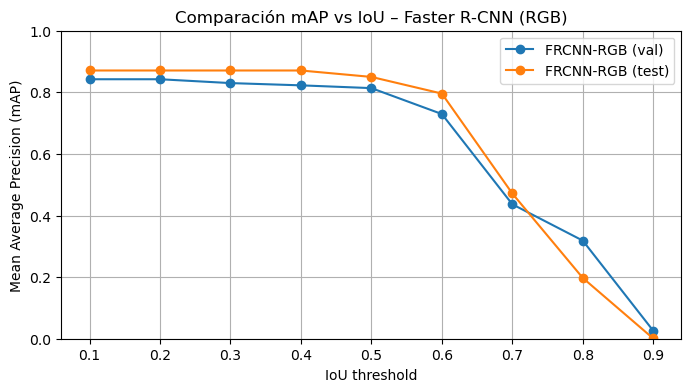

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Función auxiliar: arma la curva mAP(thr) a partir de metrics["AP_per_class"]
def get_map_curve(metrics_dict, iou_list):
    ap_per_class_iou = metrics_dict["AP_per_class"]  # dict[thr][class] = AP
    mAPs = []
    for thr in iou_list:
        aps = [v for v in ap_per_class_iou[thr].values() if not np.isnan(v)]
        mAP = float(np.mean(aps)) if len(aps) > 0 else float("nan")
        mAPs.append(mAP)
    return mAPs

# Curvas mAP vs IoU para val y test
iou_list = IOU_THRESHOLDS  # [0.5, 0.6, 0.7, 0.8, 0.9] en tu código
map_val  = get_map_curve(metrics,      iou_list)
map_test = get_map_curve(metrics_test, iou_list)

# Gráfico estilo YOLO: val + test en la misma figura
plt.figure(figsize=(8,4))
plt.plot(iou_list, map_val,  marker="o", label="FRCNN-RGB (val)")
plt.plot(iou_list, map_test, marker="o", label="FRCNN-RGB (test)")

plt.xlabel("IoU threshold")
plt.ylabel("Mean Average Precision (mAP)")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.title("Comparación mAP vs IoU – Faster R-CNN (RGB)")
plt.show()
